Telco Customer Churn 

Telco Customer Churn Prediction Analysis 
Nichelle Wilson Godad 
Tools Used: Python | SQL | Power BI | Machine Learning
Dataset: IBM Telco Customer Churn ( Kaggle ) 
Date: April 2026


Business Problem 

Customer churn is one of the most significant problems in the telecom industry. When a customer stops using the company's services, it is called churn. Acquiring new customers costs 5x more than retaining the old ones. In this project, the dataset of 7032 customers is being used to understand the reasons behind their churn and identify the customers that are likely to churn.  

Objective: Build a predictive model that identifies the most likely customers to churn and suggests retention strategies. 



Data Description 

- Data was obtained from Kaggle, which was provided by IBM. This data is publicly available. The link is: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- The data had information for 7032 customers with 21 features and is stored in CSV format.
- The features are as follows:
   - 'customerID': This uniquely identifies all the customers.
   - 'gender': Male or Female
   - 'SeniorCitizen': 1 = yes or 0 = no
   - 'Partner': yes or no
   - 'Dependents': yes or no
   - 'PhoneService': yes or no
   - 'MultipleLines': If the customer has multiple lines
   - 'InternetService': Type of internet service ( DSL/Fiber Optic / No)
   - 'OnlineSecurity': yes or no
   - 'onlineBackup': yes or no
   - 'DeviceProtection': yes or no
   - 'TechSupport': yes or no
   - 'StreamingTV': yes or no
   - 'StreamingMovies': yes or no
   - 'tenure': How long the customer has been using the company's services.
   - 'Contract': Type of contract ( Month-to-month/ one year / two year)
   - 'PaperlessBilling': yes or no
   - 'PaymentMethod': Type of payment( Electronic check, Mailed check, Bank Transfer, Credit card)
   - 'MonthlyCharges': Amount charged Monthly
   - 'TotalCharges': Total amount charged for a customer till recent service.
     



Target Variable 
The target variable for this project is 'Churn'.
'yes' : If the customer has left company
'no' : If the customer is still active

Among 7043 customers, 1869 have churned. 
The total rate of churning is 26.57%, which is among 4 customers atleast 1 customer churns. 


In [17]:
import os
os.chdir(r'C:\Users\niche\Telco-Churn-Project')
print("Working directory:", os.getcwd())

Working directory: C:\Users\niche\Telco-Churn-Project


In [18]:
import os
import pandas as pd
import sqlite3

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data Cleaning and Preprocessing

To ensure that the data was clean, accurate, and in the right format.

- Data Exploration
  The first step was to understand the dataset by examining its structure, data types, and shape.


In [19]:
df.head()
df.shape
df.dtypes
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


The dataset contains 7043 rows and 21 columns. The datatype of TotalCharges was stored as Object, which should have been numeric value. 

Missing Values and Duplicate Rows

In [20]:
#for missing values 
df.isnull().sum()
df.duplicated().sum()

0

- No missing values were found in the dataset. However, TotalCharges had missing values stored in the form of empty spaces.
- No duplicate rows were found in the dataset. 

Fixing the TotalCharges Column

The TotalCharges Column was stored as an object datatype and had empty spaces instead of actual values. 

In [21]:
df['TotalCharges'].dtype
df['TotalCharges'].head(10)
df[df['TotalCharges'] == ' ' ]
df['TotalCharges'] = df['TotalCharges'].replace(' ',float('nan'))
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
print(df['TotalCharges'].dtype)
df['TotalCharges'].dtype
df=df.dropna(subset=['TotalCharges'])
df['TotalCharges'].isnull().sum()


float64


0

- TotalCharge was successfully converted to float64.
  
- A total of 11 rows were empty in the TotalCharges Column, and these were the customers who had a tenure of 0, which means they were not charged yet.

- As only 11 rows were missing out of 7043 rows, these were dropped, as they would not significantly impact the analysis.

- After dropping the 11 rows, the dataset now contains 7032 rows.

Cleaned Dataset 

This cleaned dataset is now saved as a new CSV file, which will be further used for EDA, SQL, Power BI and ML. 

In [22]:
df.to_csv('telco_churn_clean.csv',index=False)

Exploratory Data Analysis

This will help us understand the patterns, relationships and major factors affecting the target variable. Each chart helps us understand the relationship between specific variable and churn. 

- Churn Distribution
The first step is understand how many customers have churned and how many have stayed. 

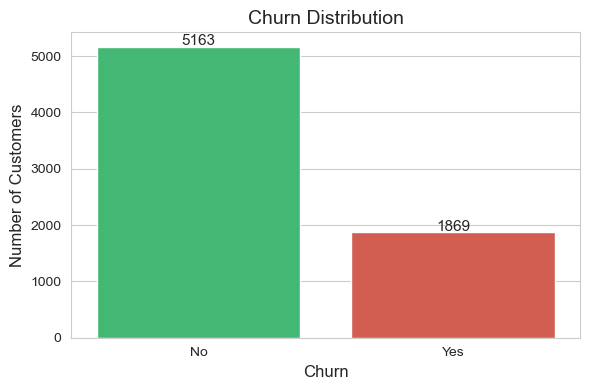

No     73.4
Yes    26.6
Name: Churn, dtype: float64


In [23]:
# chart 1 Churn Distribution 
import matplotlib.pyplot as plt
import seaborn as sns

# Count how many churned vs not churned
churn_counts = df['Churn'].value_counts()

# Set the style
sns.set_style("whitegrid")

# Create the chart
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])

# Add title and labels
plt.title('Churn Distribution', fontsize=14)
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add number labels on top of each bar
for i, count in enumerate(churn_counts):
    plt.text(i, count + 30, str(count), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Print the percentage
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate.round(1))

Insights: 
- Out of 7032 customers 1869 have churned, representing 26.6% churn rate. This churn rate is significantly is higher than average telecom industry ratw, which is 10-15%. This indicates there is serious retention problem. 

- Churn by Contract Type
This chart will explore, how customers having different contract types behave, and whether they leave the company.

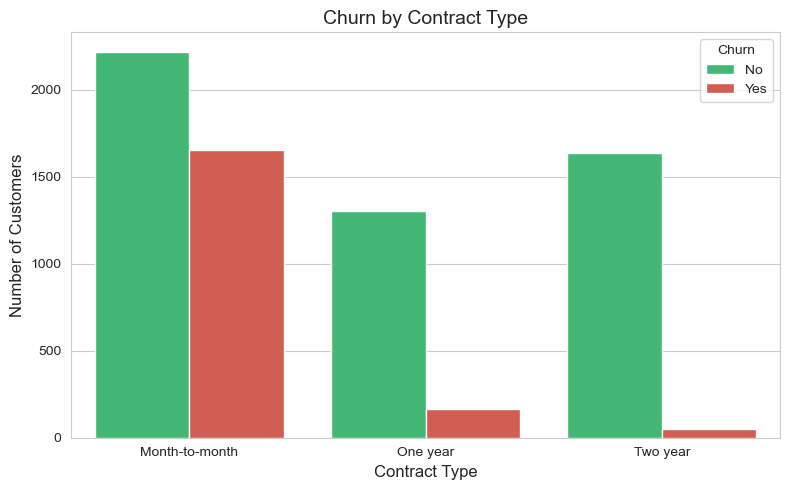

Contract        Churn
Month-to-month  No       57.3
                Yes      42.7
One year        No       88.7
                Yes      11.3
Two year        No       97.2
                Yes       2.8
Name: Churn, dtype: float64


In [24]:
#chart2 churn distribution based on contract type 
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'])

plt.title('Churn by Contract Type', fontsize=14)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churn', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

# Print the churn rate per contract type
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).mul(100).round(1))


Insights:
Customers on month to month contract type, has the highest churn rate compared to the one-year and two-year contract customers. This suggests that customers on longer contract tend to stay committed. This indicates, encouraging customers to switch to longer contracts can reduce churn. 

- Churn by Tenure
As tenure represents how long the customer has been using the services, this chart will explore whether, new customers tend to churn than the long term customers. 

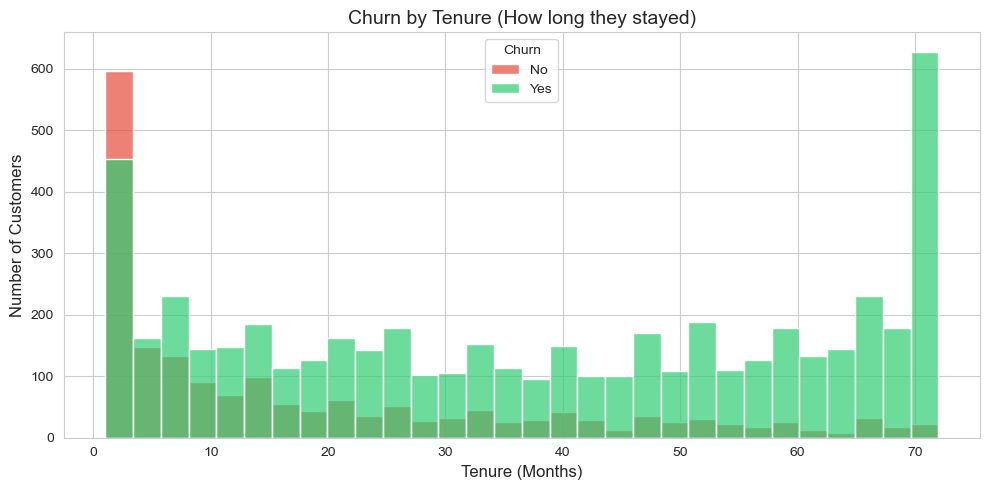

Churn
No     37.7
Yes    18.0
Name: tenure, dtype: float64


In [25]:
#chart 3 : churn by tenure 
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['#2ecc71', '#e74c3c'], alpha=0.7)

plt.title('Churn by Tenure (How long they stayed)', fontsize=14)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churn', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

# Print average tenure for churned vs not churned
print(df.groupby('Churn')['tenure'].mean().round(1))

Insights:
The histogram clearly depicts that the customers have significantly churned in the first 12 months than the ones who stayed. This suggests that first one year is crucial for the company as it have high retention rate and if they can successfully keep them beyond 12 months, they are less likely to churn. 

- Churn by Montly Charges
This chart examines whether the amount that is being paid by the customer has any correlation with churn rate 

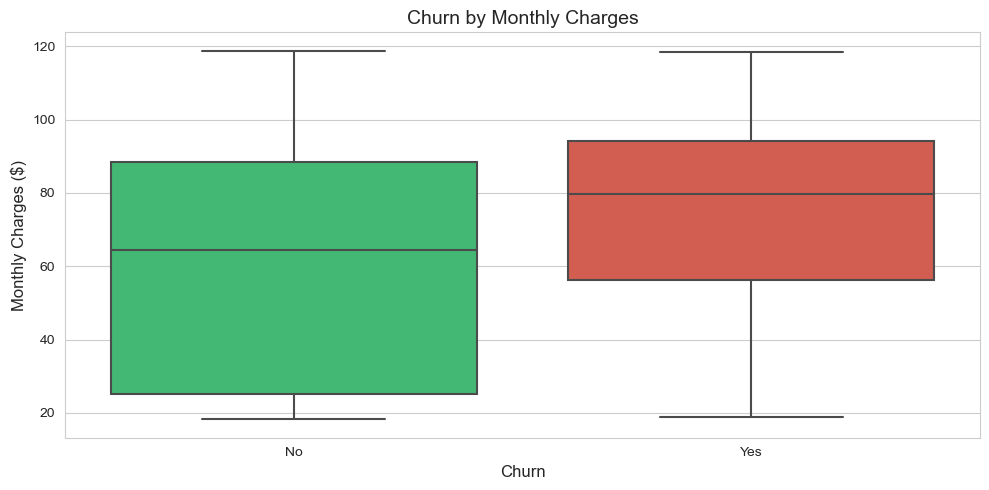

Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [26]:
#chart4: chrun by monthly charges 
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'])

plt.title('Churn by Monthly Charges', fontsize=14)
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)

plt.tight_layout()
plt.show()

# Print average monthly charges for churned vs not churned
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

The box plots shows that the customers who have churned has higher average monthly charges, than the customers who stayed. This suggests that the customers who have churned feel that they are paying too much without receiving, without equal amount of value or services. By offering discounts or better package can help reduce churn.

- Churn by Internet Service Type
As different type of Internet Service Type can attract different types of customers, this chart examines whether it affects the churn rate.

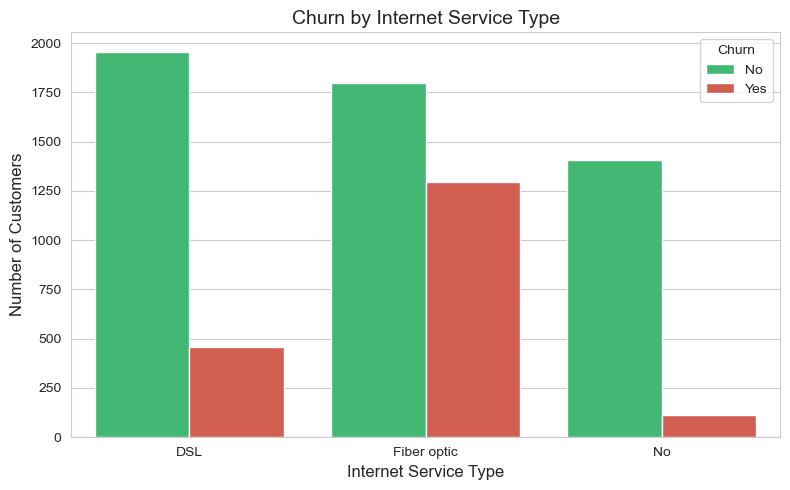

InternetService  Churn
DSL              No       81.0
                 Yes      19.0
Fiber optic      No       58.1
                 Yes      41.9
No               No       92.6
                 Yes       7.4
Name: Churn, dtype: float64


In [27]:
#chart5 : churn by internet service type 
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette=['#2ecc71', '#e74c3c'])

plt.title('Churn by Internet Service Type', fontsize=14)
plt.xlabel('Internet Service Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churn', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

# Print churn rate per internet service type
print(df.groupby('InternetService')['Churn'].value_counts(normalize=True).mul(100).round(1))


Insights: From the bar chart it is clear that Fiber optic customers have highest churn rate, desite paying premium prices. This indicates that Fiber optic customers feel that the service does not meet their expectations for the amount they are paying. And the customers with no internet service has the lowest churn rate. 

- Churn by Senior Citizen Status 
This chart explores whether senior citizens behave differently from the younger ones, in the terms of churn rate.

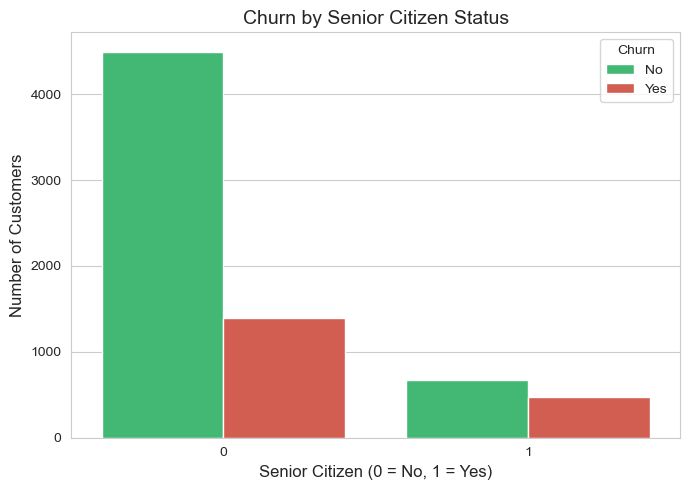

SeniorCitizen  Churn
0              No       76.3
               Yes      23.7
1              No       58.3
               Yes      41.7
Name: Churn, dtype: float64


In [28]:
#chart6 : chrun rate by age
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette=['#2ecc71', '#e74c3c'])

plt.title('Churn by Senior Citizen Status', fontsize=14)
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churn', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

# Print churn rate for senior vs non-senior
print(df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).mul(100).round(1))

Insights:
The senior citizens have high churn rate than the younger ones, suggesting than even though they are in small portion, they might need personalized support or simpler plans according to their needs. 

# SQL Analysis 

To understand and extract business insights in a structured way. The SQLite database was created from the cleaned python dataframe as it allows SQL queries to run within Jupyter Notebook. 

In [29]:
import sqlite3

# Create a database connection
conn = sqlite3.connect('churn_database.db')

# Load clean dataframe into the database
df.to_sql('customers', conn, if_exists='replace', index=False)
print("Database created and data loaded successfully!")

Database created and data loaded successfully!


In [30]:
# Helper function to run SQL queries
def run_query(query):
    result = pd.read_sql_query(query, conn)
    return result

# overall churn rate 
result = run_query("""
    SELECT 
        Churn,
        COUNT(*) as Total_Customers,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customers), 1) as Percentage
    FROM customers
    GROUP BY Churn
""")
print(result)

  Churn  Total_Customers  Percentage
0    No             5163        73.4
1   Yes             1869        26.6


Query 1 
- Churn by Contract Type
  
This query calculates the total customers and the number of customers churned and their churn rate based on different contract types, to understand which contract type has highest churn.

In [31]:
#query1: : chrun by contract type 
result = run_query("""
    SELECT 
        Contract,
        COUNT(*) as Total_Customers,
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as Churned,
        ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as Churn_Rate
    FROM customers
    GROUP BY Contract
    ORDER BY Churn_Rate DESC
""")
print(result)

         Contract  Total_Customers  Churned  Churn_Rate
0  Month-to-month             3875     1655        42.7
1        One year             1472      166        11.3
2        Two year             1685       48         2.8


Insights: 
Month-to-month contract customers have the highest churn rate, which is 42.7%, which confirms the insights seen in EDA. Customers on a two-year contract has lowest churn rate, which is 2.8%. This suggests that customers on long term contract have low rentention rate.  

Query 2

- Average Monthly Charges: churned vs Loyal

This query compares the average monthly charges, total charges, and tenure between the churned and loyal customers and understands the amount different paid by each of them. 

In [32]:
#Query2 : : average monthly charges: churned vs loyal 
result = run_query("""
    SELECT 
        Churn,
        ROUND(AVG(MonthlyCharges), 2) as Avg_Monthly_Charge,
        ROUND(AVG(TotalCharges), 2) as Avg_Total_Charge,
        ROUND(AVG(tenure), 1)  as Avg_Tenure_Months
    FROM customers
    GROUP BY Churn
""")
print(result)

  Churn  Avg_Monthly_Charge  Avg_Total_Charge  Avg_Tenure_Months
0    No               61.31           2555.34               37.7
1   Yes               74.44           1531.80               18.0


Insights:
Churned customers have been paying high average monthly charges, but have low tenure and Total charges, suggesting that the customers who pay more but for shorter period, are most likely to churn. 

Query 3

- Churn Rate by Internet Service Type

This query examines the churn rate and average monthly charges across different internet service type. 

In [33]:
#query3 : churn rate by internet service type 
result = run_query("""
    SELECT 
        InternetService,
        COUNT(*) as Total_Customers,
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as Churned,
        ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as Churn_Rate,
        ROUND(AVG(MonthlyCharges), 2) as Avg_Monthly_Charge
    FROM customers
    GROUP BY InternetService
    ORDER BY Churn_Rate DESC
""")
print(result)

  InternetService  Total_Customers  Churned  Churn_Rate  Avg_Monthly_Charge
0     Fiber optic             3096     1297        41.9               91.50
1             DSL             2416      459        19.0               58.09
2              No             1520      113         7.4               21.08


Insights:
As seen in the EDA, Fiber Optic customers have been paying the highest average monthly charges and also have the highest churn rate. This indicates that they feel they do not receive enough benefits for the value they are paying. 

Query 4

- Churn rate by Senior Citizen

This query will compare the churn rate between the senior citizen and the younger generation. 

In [34]:
#query 4 : churn rate by senior citizen 
result = run_query("""
    SELECT 
        CASE WHEN SeniorCitizen = 1 THEN 'Senior' ELSE 'Non-Senior' END as Customer_Type,
        COUNT(*) as Total_Customers,
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as Churned,
        ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as Churn_Rate,
        ROUND(AVG(MonthlyCharges), 2) as Avg_Monthly_Charge
    FROM customers
    GROUP BY SeniorCitizen
    ORDER BY Churn_Rate DESC
""")
print(result)

  Customer_Type  Total_Customers  Churned  Churn_Rate  Avg_Monthly_Charge
0        Senior             1142      476        41.7               79.82
1    Non-Senior             5890     1393        23.7               61.89


Insights:
It's observed that senior citizens have been paying a high monthly average charge as well have high churn rate as compared to the younger generation. This suggests that they are not satisfied with the services they are receiving for the charges they pay and may need more affordable and simplified packages. 

Query 5

- Top 10 Highest Paying churned customers

This query will examine the top 10 highest paying customers according to the average monthly charges. This will represent the customers that the company has already lost.

In [35]:
#query 5 : top 10 paying churned customers 
result = run_query("""
    SELECT 
        customerID,
        MonthlyCharges,
        TotalCharges,
        tenure,
        Contract,
        InternetService
    FROM customers
    WHERE Churn = 'Yes'
    ORDER BY MonthlyCharges DESC
    LIMIT 10
""")
print(result)

   customerID  MonthlyCharges  TotalCharges  tenure        Contract  \
0  8199-ZLLSA          118.35       7804.15      67        One year   
1  2889-FPWRM          117.80       8684.80      72        One year   
2  2302-ANTDP          117.45       5438.90      48  Month-to-month   
3  9053-JZFKV          116.20       7752.30      67        Two year   
4  1444-VVSGW          115.65       7968.85      70        One year   
5  0201-OAMXR          115.55       8127.60      70        One year   
6  4361-BKAXE          114.50       4527.45      41  Month-to-month   
7  1555-DJEQW          114.20       7723.90      70        Two year   
8  9158-VCTQB          113.60       4594.95      41  Month-to-month   
9  7279-BUYWN          113.20       4689.50      41  Month-to-month   

  InternetService  
0     Fiber optic  
1     Fiber optic  
2     Fiber optic  
3     Fiber optic  
4     Fiber optic  
5     Fiber optic  
6     Fiber optic  
7     Fiber optic  
8     Fiber optic  
9     Fiber optic 

Insights:

The top 10 highest-paying churned customers were all Fiber Optic customers, who were paying a monthly average charge from $113.20  to $118.35. 
Surprisingly, not all of the customers were on month-to-month contracts; some were on one-year and two-year contracts and still churned. This indicates that even though they were on a long-term contract, they still churned. This highest-paying customer paid $118.35 per month, had a tenure of 67 months, and a total charge of $7,084.15, yet still churned. This clearly highlights that fiber optic pricing and service quality needs to be addressed. 

Query 6 

- Churn by Tenure

This query groups the customers according to the tenure buckets and calculates the churn rate to understand when the customer is most likely to churn. 

In [36]:
#query6 : churn tenure group 
result = run_query("""
    SELECT 
        CASE 
            WHEN tenure BETWEEN 0 AND 12 THEN '0-12 Months (New)'
            WHEN tenure BETWEEN 13 AND 24 THEN '13-24 Months (Growing)'
            WHEN tenure BETWEEN 25 AND 48 THEN '25-48 Months (Established)'
            ELSE '49+ Months (Loyal)'
        END as Tenure_Group,
        COUNT(*) as Total_Customers,
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as Churned,
        ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as Churn_Rate
    FROM customers
    GROUP BY Tenure_Group
    ORDER BY Churn_Rate DESC
""")
print(result)

                 Tenure_Group  Total_Customers  Churned  Churn_Rate
0           0-12 Months (New)             2175     1037        47.7
1      13-24 Months (Growing)             1024      294        28.7
2  25-48 Months (Established)             1594      325        20.4
3          49+ Months (Loyal)             2239      213         9.5


Insights:

The group of new customers with a tenure of 1 to 12 months has the highest churn rate, while the oldest customers with a tenure of 49+ months have the lowest churn rate. This highlights that the customers have a high retention rate in the first 12 months, and the company should focus on addressing this issue. 

Query 7

- Identifying High Risk Customers

This query is the most important query, as it identifies the currently active customers who are at high risk of churning based on the combination of risk factors such as a month-to-month contract, fiber optic service, high monthly charges, and low tenure. This query helps the retention team to proactively reach out to these customers before they leave. 

In [37]:
#query 7 : high risk customers right now
result = run_query("""
    SELECT 
        customerID,
        Contract,
        InternetService,
        MonthlyCharges,
        tenure,
        CASE WHEN SeniorCitizen = 1 THEN 'Yes' ELSE 'No' END as Senior,
        CASE 
            WHEN Contract = 'Month-to-month' 
            AND InternetService = 'Fiber optic'
            AND MonthlyCharges > 74
            AND tenure < 18
            THEN 'Very High Risk'
            WHEN Contract = 'Month-to-month' 
            AND MonthlyCharges > 65
            THEN 'High Risk'
            ELSE 'Normal'
        END as Risk_Level
    FROM customers
    WHERE Churn = 'No'
    AND (
        Contract = 'Month-to-month' 
        AND MonthlyCharges > 65
    )
    ORDER BY MonthlyCharges DESC
""")

print(f"Total at-risk customers: {len(result)}")
print(f"Very High Risk: {len(result[result['Risk_Level'] == 'Very High Risk'])}")
print(f"High Risk: {len(result[result['Risk_Level'] == 'High Risk'])}")
print(result.head(10))

Total at-risk customers: 1106
Very High Risk: 275
High Risk: 831
   customerID        Contract InternetService  MonthlyCharges  tenure Senior  \
0  8016-NCFVO  Month-to-month     Fiber optic          116.50      55    Yes   
1  9659-QEQSY  Month-to-month     Fiber optic          115.65      45     No   
2  6710-HSJRD  Month-to-month     Fiber optic          114.10      61     No   
3  0771-WLCLA  Month-to-month     Fiber optic          112.95      16     No   
4  9481-IEBZY  Month-to-month     Fiber optic          112.90      72    Yes   
5  2587-EKXTS  Month-to-month     Fiber optic          111.50      44     No   
6  7130-YXBRO  Month-to-month     Fiber optic          111.45      48     No   
7  3292-PBZEJ  Month-to-month     Fiber optic          111.40      11    Yes   
8  6168-YBYNP  Month-to-month     Fiber optic          111.35      59     No   
9  2067-QYTCF  Month-to-month     Fiber optic          111.15      64     No   

       Risk_Level  
0       High Risk  
1       High R

Insights:
- There are total 1106 currently active customers who are at the risk of churning. Among which 275 are very high risk and 831 are at high risk. 
- These customers are still using the services but have the same factors of the customers who have churned such as month-to-month contracts, fiber optic internet servive, high monthly charges and low tenure.
- By observing the first 10 high risk customers, all of them are month-to-month with fiber internet service and are paying above $ 111 per month. some of these are with the comapny on a long contract yet classified as high risk due to contract type and high monthly charges.
- The 275 customers at very high risk are paying above $ 75, month-to-month contract and uses fiber optic service and has a tenure less than 18 months. These should be the priority to the company.
- Through this query, we can transform the analysis from historical reporting into a real busines action plan, This will surely help the rentention team to immediately target and offer these customers incentives to prevent further loss. 

# Power BI 

An interactive Power BI dashboard was built to present the churn findings to the business stakeholders in a visual and easy-to-understand format. It has two pages covering the overview and a deep dive into churing patterns. 

Page 1 — Overview Dashboard


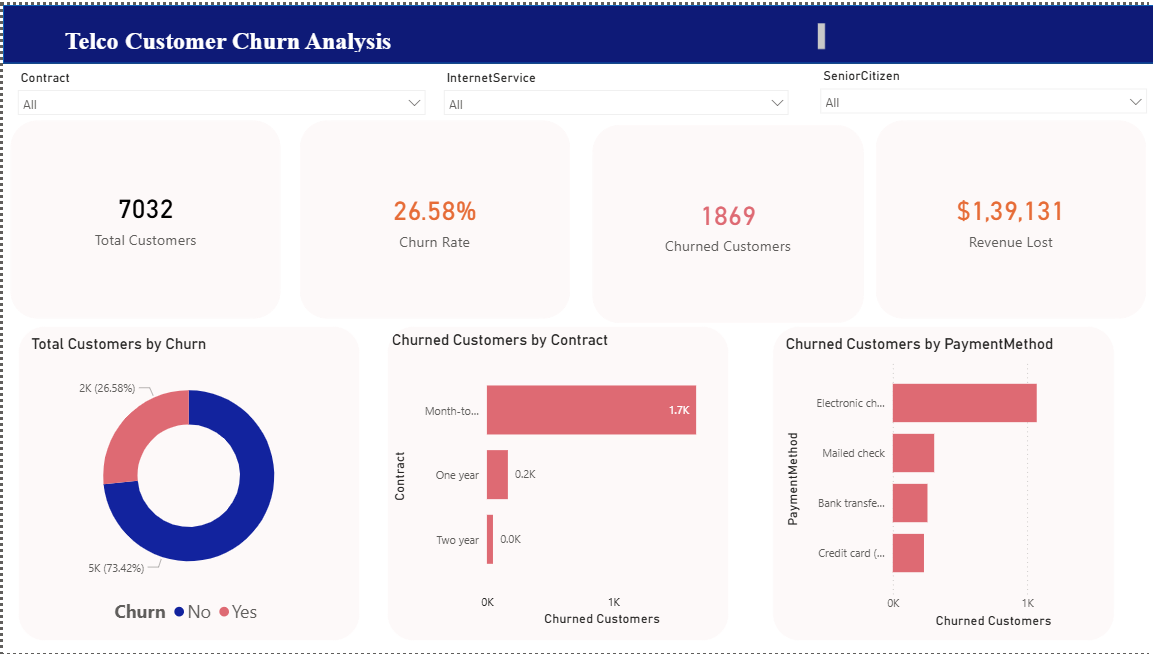

In [50]:
from IPython.display import Image, display

print("Page 1 — Overview Dashboard")
display(Image('page1_overview.png', width=900))

Observations:

The overview dashboard reveals that out of 7032 customers, 1869 customers have churned, and the churn rate is 26.58%, which indicates that there is a serious retention problem. The total revenue lost from these churned customers is $139,131. This churn has a big financial impact on the business. 

The donut chart confirms the 73.42% vs 26.58% split between retained and churned customers. The contract type charts clearly show that the month-to-month contract customers have a high churn rate, compared to the one-year and two-year contracts. 

Customers using electronic checks as a payment method have the highest churn rate compared to those using mailed checks, bank transfer, and credit card users. 


Page 2 — Deep Dive Dashboard


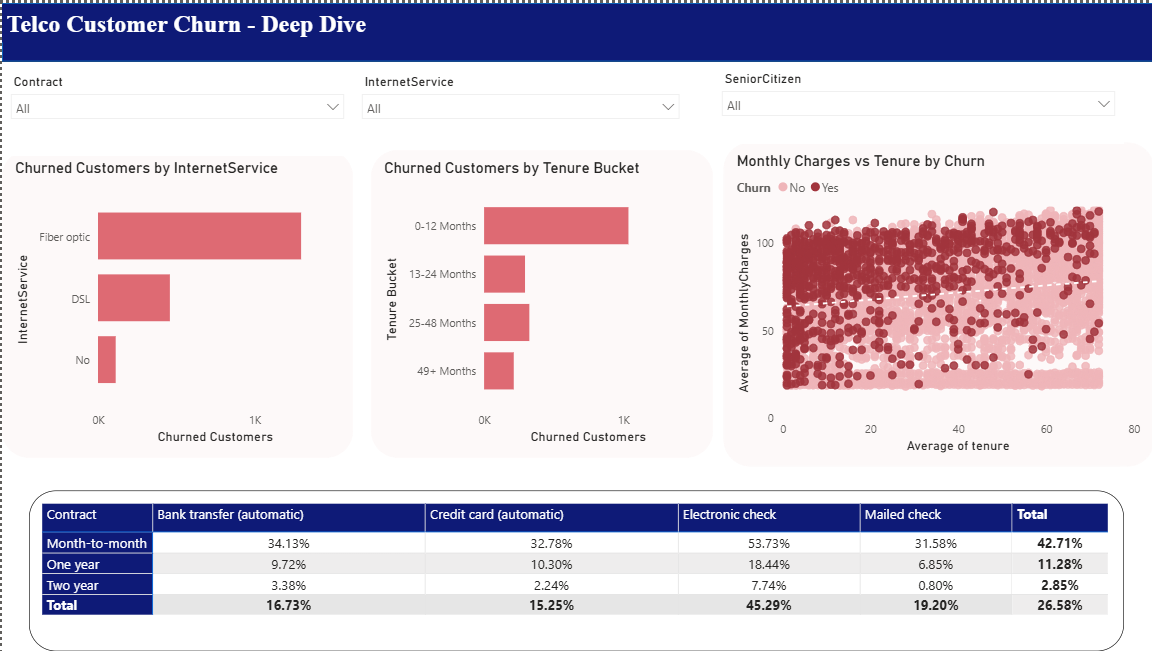

In [51]:
print("Page 2 — Deep Dive Dashboard")
display(Image('page2_deepdive.png', width=900))

The deep dive dashboard does further analysis into churn patterns across different customer segments. 

The internet service chart shows that Fiber optic customers have the highest churn rate, even though they are paying premium prices. While the customers with no internet service have the lowest churn rate. 

The Tenure bucket chart shows that the customers within 0-12 months have the highest churn rate, confirming that the first year is the most crucial period for customer retention. The churn rate drops significantly after 49+ months. 

The scatter plot shows that the churned customers ( in the red spots ) tend to cluster in high monthly charges, confirming that the customers paying more are more likely to churn. 

The matrix table gives us the granular insights. The month-to-month customers, having an electronic check as the payment method, have the highest churn rate at 54%, making them the highest risk segment. The two-year contract customers have the lowest churn rate across all the payment methods. 

# Machine Learning Models 

After EDA, SQL Analysis, and Power BI, ML models were trained to predict the customers who are most likely to churn. Three models were trained and compared to find the best performing one. 

In [39]:
#import libraries and load data 
#ML MODELLING 

!pip install xgboost
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
from xgboost import XGBClassifier

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('churn_powerbi.csv')
print(df.shape)
df.head()

(7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Preprocessing for ML

- Before training the models, the CustomerID column was dropped, as it was just an identifier and of no use in predicting the value. 
- All the text columns were converted to numeric using label encoding. 
- Using StandardScaler, all the numerical features were brought to the same range, ensuring no feature dominates other. 

In [40]:
df.shape
# Drop customerID as it's not useful for ML
df = df.drop('customerID', axis=1)

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Separate categorical and numerical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

# Encode categorical columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nData types after encoding:")
print(df.dtypes)
print("\nShape:", df.shape)

# Train and test data split 
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Check class balance
print("\nChurn distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # for reproducibility
    stratify=y          # keeps same churn ratio in both sets
)

print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nData is ready for modeling!")

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Data types after encoding:
gender                int32
SeniorCitizen         int64
Partner               int32
Dependents            int32
tenure                int64
PhoneService          int32
MultipleLines         int32
InternetService       int32
OnlineSecurity        int32
OnlineBackup          int32
DeviceProtection      int32
TechSupport           int32
StreamingTV           int32
StreamingMovies       int32
Contract              int32
PaperlessBilling      int32
PaymentMethod         int32
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Shape: (7032, 20)
Features shape: (7032, 19)
Target shape: (7032,)

Churn distribution:
0    5163
1    1869
Name: Churn, dtype: int64
0 

Train Test Split 

- The dataset was split into 80% training and 20% testing. The training set was used to train the model and the testing set to evaluate how well it performs on the unseen data.
- Here, stratify = y is used to ensure that both sets have the same proportion of churned and no -churned customers. 

Model Training 

Three models were selected and trained:
- Logistic Regression
- Random Forest
- XGBoost

In [42]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train all models and store results
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Score
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy,
        'roc_auc': roc_auc
    }
    
    print(f"{name}:")
    print(f"  Accuracy : {accuracy:.4f}")
    print(f"  ROC-AUC  : {roc_auc:.4f}")
    print()

Logistic Regression:
  Accuracy : 0.7939
  ROC-AUC  : 0.8345

Random Forest:
  Accuracy : 0.7818
  ROC-AUC  : 0.8107

XGBoost:
  Accuracy : 0.7647
  ROC-AUC  : 0.8044



Insights:
Logistic Regression outperformed both Random Forest and XGBoost, which suggests that the relationship between features and churn rate is linear in nature. And all the have have ROC-AUC score above 0.80 suggesting that the models performed good.

Model Evaluation

For deeper evaluation, we performed a classification report and confusion matrix for each model. 

Logistic Regression

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.86      1033
       Churn       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



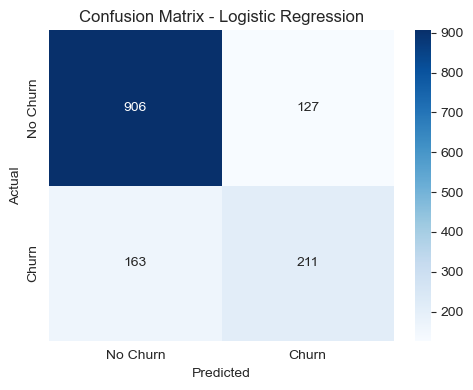


Random Forest

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



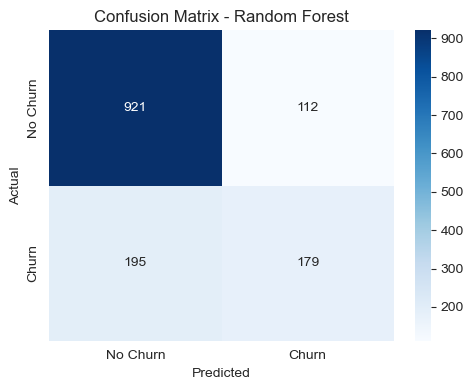


XGBoost

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.86      0.84      1033
       Churn       0.56      0.51      0.53       374

    accuracy                           0.76      1407
   macro avg       0.70      0.68      0.69      1407
weighted avg       0.76      0.76      0.76      1407



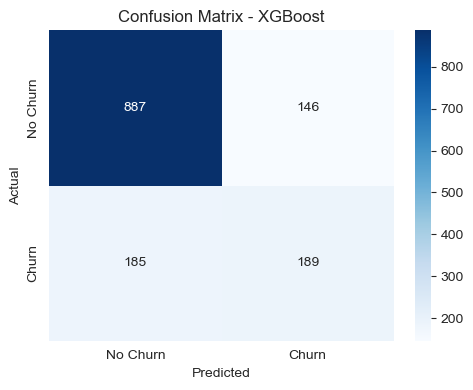

In [43]:
# Detailed evaluation for each model
for name, result in results.items():
    print(f"{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, result['y_pred'], 
                                target_names=['No Churn', 'Churn']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, result['y_pred'])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    print()

Insights:
The logistic regression model achieved a churn recall of 56%, suggesting that it missed 44% of actual churners. While the accuracy was good at 79.39%, the low recall indicates that the model needs improvements to be useful for business retention campaigns. 


Feature Importance

Feature importance is a necessary part as it tells us which factors have most influence on whether a customer churns or not. This is extracted from the random forest model as it naturally provides a feature importance score. Understanding the feature importance is very important as it shows the business where to exactly focus. 

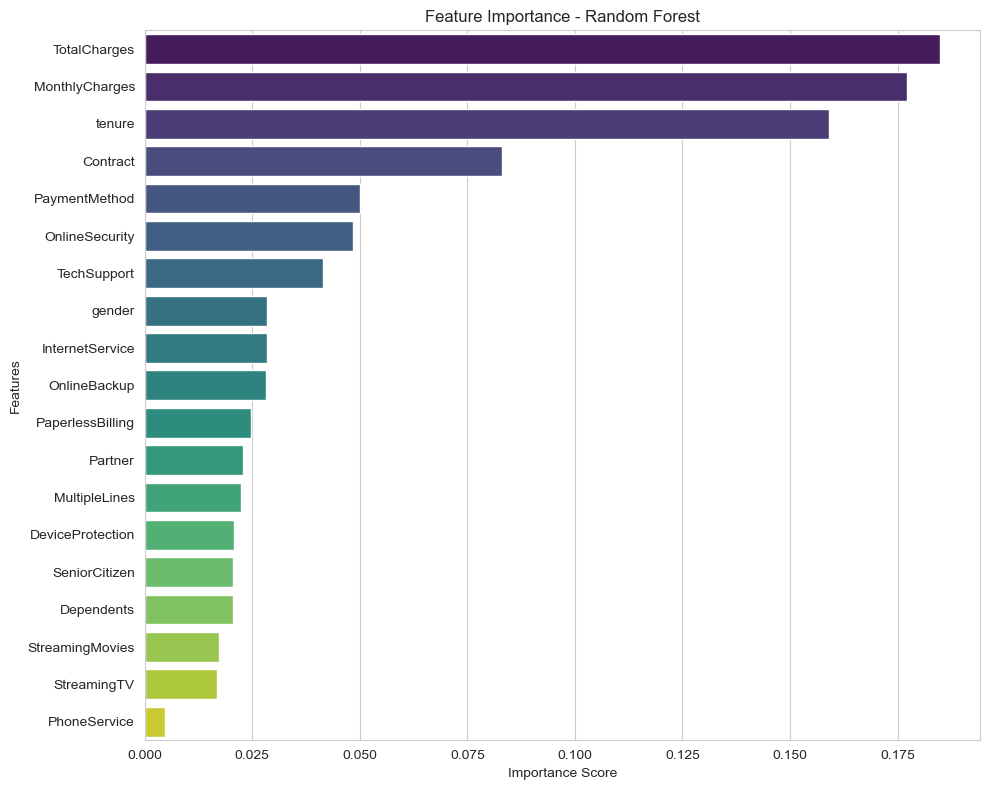

Top 10 Most Important Features:
        Feature  Importance
   TotalCharges    0.184908
 MonthlyCharges    0.177222
         tenure    0.159101
       Contract    0.083028
  PaymentMethod    0.050095
 OnlineSecurity    0.048429
    TechSupport    0.041551
         gender    0.028497
InternetService    0.028416
   OnlineBackup    0.028212


In [44]:
# Feature importance using Random Forest
rf_model = results['Random Forest']['model']

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': df.drop('Churn', axis=1).columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print top 10
print("Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

Insights:

The top three features are related to finance and time, confirming that the price strategies and early customer engagement are important factors in reducing churn.

Hyperparameter Tuning

As we have noticed from the previous results, the churn recall is 56% only, which misses almost half of the customers who are about to churn. By performing hyperparameter tuning, we are improving this. 

GridSearchCV is used to try 20 different combinations of parameters with 5-fold cross-validation, totalling 100 training runs. The model was optimized for recall to catch maximum number of churns. 

In [45]:
#Hyperparameter tuning 
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced', None]
}

# Grid Search
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,                    # 5-fold cross validation
    scoring='recall',        # optimize for recall
    n_jobs=-1,               # use all CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Recall Score:", grid_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best Recall Score: 0.8394648829431437


Insights:

The Best Cross Validation Recall is 83.94%

Tuned Model Evaluation 

The tuned model was evaluated against the original model to measure the improvement that is achieved by hyperparameter tuning. 


All libraries loaded and data ready!
X_train shape: (5625, 19)
Tuned Logistic Regression Results:
              precision    recall  f1-score   support

    No Churn       0.91      0.67      0.77      1033
       Churn       0.47      0.81      0.60       374

    accuracy                           0.71      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.79      0.71      0.73      1407



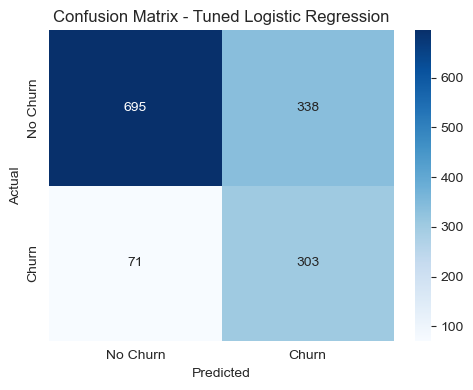


Before vs After Tuning:
Recall (Churn) Before: 56%
Recall (Churn) After : 83.01%


In [46]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('churn_powerbi.csv')

# Preprocessing
df = df.drop('customerID', axis=1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Split
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("All libraries loaded and data ready!")
print("X_train shape:", X_train.shape)

# Get best model
best_model = grid_search.best_estimator_

# Predict
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

# Classification Report
print("Tuned Logistic Regression Results:")
print(classification_report(y_test, y_pred_tuned,
                            target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Compare before vs after
print("\nBefore vs After Tuning:")
print(f"Recall (Churn) Before: 56%")
print(f"Recall (Churn) After : {roc_auc_score(y_test, y_prob_tuned):.2%}")

Insights:

Although there was a slight drop in the accuracy, churn recall has significantly increased from 56% to 81%. This means that the tuned model can identify 4 out of 5 customers who are about to churn. This insight is important for retention campaigns. 
Here, the trade-off between the accuracy and recall is acceptable as identifying a churner is much more important. 

ROC Curve Comparison 

The ROC curve compares how well a model has separated churned vs no-churned customers. A higher AUC suggests that the model has performed well. The score being 0.5 is a random guess, and the score of 1.0 is a perfect prediction. 


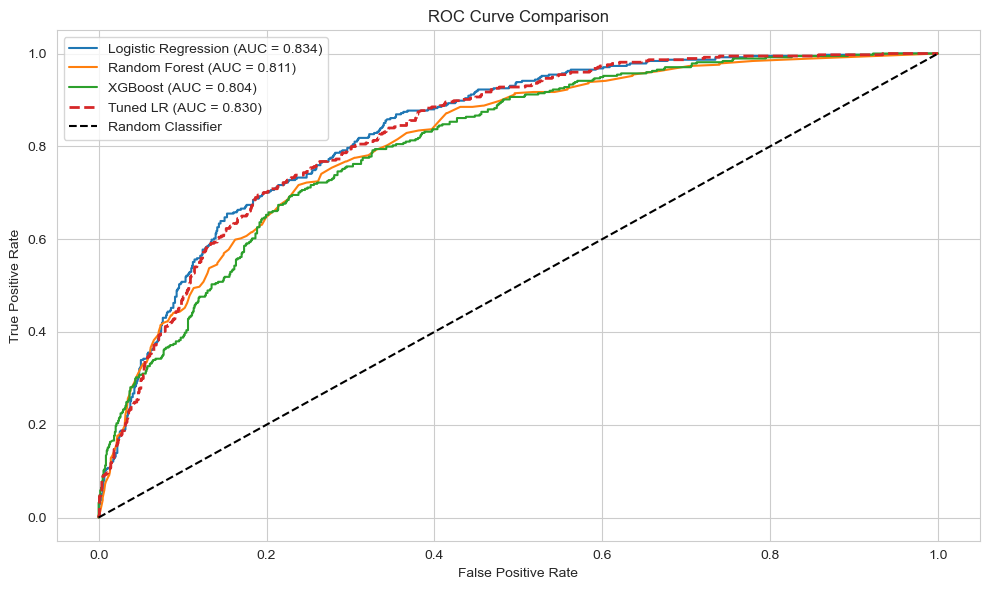

In [47]:
# ROC Curve for all models + tuned model
plt.figure(figsize=(10, 6))

# Original models
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    auc = roc_auc_score(y_test, result['y_prob'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

# Tuned model
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)
auc_tuned = roc_auc_score(y_test, y_prob_tuned)
plt.plot(fpr_tuned, tpr_tuned, 
         label=f'Tuned LR (AUC = {auc_tuned:.3f})',
         linestyle='--', linewidth=2)

# Random line
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

All three models have an AUC scored above 0.80, confirming good discriminatory ability. Logistic Regression achieved the highest AUC of 0.8345, making it the best model of the dataset. The ROC curve confirms that our models have performed significantly better than random guessing across all the classification thresholds. 

Key Business Recommendations 

Based on the findings from EDA, SQL Analysis, Power BI dashboard, and Machine Learning models, these recommendations are proposed to help the business reduce customer churn. 

- Focusing on new customers ( 0 - 12 months ) as they have the highest churn rate in SQL Query, and Tenure was the 3rd most important feature in ML. Offering discounts for switching to annual contracts would reduce churn.
- Electronic users have the highest churn rate, and switching them to automatic payment methods with small discounts will retain them.
- Fiber optic customers have a high churn rate, so the service quality and pricing should be revised.
- SQL analysis showed 1106 customers are at high risk of churning; targeting these customers should be prioritized. 


 Conclusion 

This project has successfully delivered an end-to-end churn prediction analysis for a telcom company using a dataset of 7032 customers. 

Through analysis such as EDA, SQL, Power BI dashboards, and machine learning, the top drivers of churn were tenure, monthly charges, contract type, and payment method. The logistic regression model was used, and it showed churn recall of 81%, meaning it correctly identified 4 out of 5 customers who are likely to churn. 

Its main finding was identifying 1106 customers who were at high risk of churn, as these had the same characteristics of the churned customers. 

The limitation is that the dataset is from 2017, and the model has not been deployed to production. 